# Самостоятельная работа: GBDT для задачи Traffic & Mobility на геоданных Санкт-Петербурга

## Тема
**Оценка потенциальной транспортной нагрузки на сегменты уличной сети Санкт-Петербурга** с использованием геометрических и пространственных признаков.

В этом ноутбуке вам нужно самостоятельно завершить пайплайн машинного обучения:

1. загрузить реальные геоданные из OpenStreetMap;
2. подготовить геометрию дорожных сегментов;
3. извлечь геометрические признаки;
4. добавить признаки городского окружения;
5. сформировать целевую переменную-прокси;
6. обучить модель GBDT;
7. оценить качество модели;
8. визуализировать прогноз на карте.

> Важно: это учебная задача. Мы не используем реальные датчики трафика, поэтому целевая переменная будет **прокси-показателем транспортной нагрузки**. В реальных проектах её можно заменить на данные с детекторов, GPS-треков, скорости движения, ДТП или общественного транспорта.

## 0. Установка и импорт библиотек

Запустите ячейку ниже. Если часть библиотек не установлена, раскомментируйте установку.

In [1]:
!pip install osmnx geopandas shapely scikit-learn matplotlib contextily mapclassify

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

from shapely.geometry import box
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.neighbors import BallTree

Defaulting to user installation because normal site-packages is not writeable


## 1. Область исследования

Используем bbox для центральной части Санкт-Петербурга. При желании можно изменить границы, но слишком большая область будет долго загружаться.

Формат bbox: `(west, south, east, north)`.

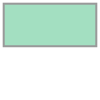

In [2]:
# Центральная часть Санкт-Петербурга
bbox = (30.18, 59.86, 30.55, 60.03)
polygon_wgs = box(*bbox)

polygon_wgs

## 2. Загрузка уличной сети из OpenStreetMap

В этой части нужно загрузить граф автомобильной дорожной сети и преобразовать его в GeoDataFrame с рёбрами.

### Задание 1
Заполните пропуски `...` так, чтобы:

- загрузить граф дорог через `ox.graph_from_polygon`;
- использовать тип сети `drive`;
- получить таблицу рёбер через `ox.graph_to_gdfs`.

In [3]:
# TODO: загрузите граф дорожной сети
G = ox.graph_from_polygon(
    polygon_wgs,                 # polygon_wgs
    network_type= "drive",    # "drive"
    simplify=True,
    retain_all=False
)

# TODO: получите GeoDataFrame узлов и рёбер
gdf_nodes, gdf_edges = ox.graph_to_gdfs(G)

print(gdf_edges.shape)
gdf_edges.head()

(16176, 15)


osmid       highway lanes  maxspeed  \
u      v          key                                                          
219808 2327840    0                   33997807  primary_link     2  RU:urban   
       389449562  0                  201380605       primary     3  RU:urban   
219811 1832085962 0                   33997784  primary_link     2  RU:urban   
       1465050831 0    [1123339577, 178581714]       primary     3  RU:urban   
219812 249890545  0                    4459876       primary     2  RU:urban   

                       oneway reversed      length                       name  \
u      v          key                                                           
219808 2327840    0     False    False   26.026139                        NaN   
       389449562  0      True    False   31.504625         Лиговский проспект   
219811 1832085962 0     False    False   27.905147                        NaN   
       1465050831 0      True    False  394.654005         Лиговский проспект   
219812 249890545  0      True    False   33.758153  Воздухоплавательная улица   

                                                                geometry  \
u      v          key                                                      
219808 2327840    0    LINESTRING (30.33142 59.89509, 30.33109 59.89526)   
       389449562  0    LINESTRING (30.33142 59.89509, 30.33182 59.89529)   
219811 1832085962 0      LINESTRING (30.33748 59.8993, 30.33793 59.8992)   
       1465050831 0    LINESTRING (30.33748 59.8993, 30.3372 59.89897...   
219812 249890545  0    LINESTRING (30.33955 59.90173, 30.33982 59.90146)   

                      bridge junction  ref width tunnel access  
u      v          key                                           
219808 2327840    0      NaN      NaN  NaN   NaN    NaN    NaN  
       389449562  0      NaN      NaN  NaN   NaN    NaN    NaN  
219811 1832085962 0      NaN      NaN  NaN   NaN    NaN    NaN  
       1465050831 0      NaN      NaN  NaN   NaN    NaN    NaN  
219812 249890545  0      NaN      NaN  NaN   NaN    NaN    NaN

## 3. Приведение к метрической системе координат

Для расстояний, длин и площадей нельзя использовать градусы широты/долготы. Нужно перейти в метрическую проекцию.

Для Санкт-Петербурга можно использовать, например, `EPSG:32636`.

### Задание 2
Создайте копию `edges_m`, переведённую в метрическую CRS.

In [4]:
# TODO: переведите дороги в метрическую CRS
edges_m = gdf_edges.to_crs("EPSG:32636")

# Проверка
edges_m.crs

<Projected CRS: EPSG:32636>
Name: WGS 84 / UTM zone 36N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 30°E and 36°E, northern hemisphere between equator and 84°N, onshore and offshore. Belarus. Cyprus. Egypt. Ethiopia. Finland. Israel. Jordan. Kenya. Lebanon. Moldova. Norway. Russian Federation. Saudi Arabia. Sudan. Syria. Türkiye (Turkey). Uganda. Ukraine.
- bounds: (30.0, 0.0, 36.0, 84.0)
Coordinate Operation:
- name: UTM zone 36N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

## 4. Базовые геометрические признаки дорожных сегментов

Для каждого сегмента дороги можно извлечь признаки из его геометрии:

- длина сегмента;
- координаты центроида;
- прямое расстояние между началом и концом линии;
- извилистость;
- направление сегмента.

### Задание 3
Допишите вычисление признаков.

In [5]:
roads = edges_m.copy()

# Длина сегмента в метрах
roads["length_m_geom"] = roads.geometry.length

# Центроид сегмента
roads["centroid_x"] = roads.geometry.centroid.x
roads["centroid_y"] = roads.geometry.centroid.y

# Функция для прямого расстояния между началом и концом LineString
# Подсказка: geom.coords[0] — первая точка, geom.coords[-1] — последняя точка

def straight_distance(geom):
    coords = list(geom.coords)
    x1, y1 = coords[0]
    x2, y2 = coords[-1]
    d = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
    return d  # TODO: евклидово расстояние

roads["straight_dist_m"] = roads.geometry.apply(straight_distance)

# Извилистость: отношение длины линии к прямому расстоянию
roads["sinuosity"] = roads["length_m_geom"] / roads["straight_dist_m"].replace(0, np.nan)
roads["sinuosity"] = roads["sinuosity"].replace([np.inf, -np.inf], np.nan).fillna(1)

# Направление дороги в радианах
# Подсказка: используйте np.arctan2(dy, dx)
def segment_angle(geom):
    coords = list(geom.coords)
    x1, y1 = coords[0]
    x2, y2 = coords[-1]
    dx = x2 - x1
    dy = y2 - y1
    return np.arctan2(dy, dx)

roads["angle_rad"] = roads.geometry.apply(segment_angle)
roads[["length_m_geom", "straight_dist_m", "sinuosity", "angle_rad"]].describe()

,length_m_geom,straight_dist_m,sinuosity,angle_rad
count,16176.000000,16176.000000,16176.000000,16176.000000
mean,183.554633,177.120246,1.045379,0.001167
std,243.995907,228.388397,0.896788,1.818570
min,1.236514,0.000000,1.000000,-3.141433
25%,28.296945,27.432919,1.000000,-1.582503
50%,106.825070,104.682539,1.000018,-0.000176
75%,248.837794,243.176946,1.002707,1.554398
max,6640.370574,5357.940848,76.797540,3.140873


## 5. Категориальные признаки дороги

В OSM у дорог есть тег `highway`: motorway, primary, secondary, tertiary, residential и т.д.

GBDT в `scikit-learn` обычно работает с числовыми признаками, поэтому категориальные признаки нужно закодировать.

### Задание 4
Сделайте one-hot encoding для признака `highway`.

Подсказка: иногда `highway` может быть списком. Код ниже уже приводит его к строке.

In [10]:
roads["highway_str"] = roads["highway"].apply(
    lambda x: x[0] if isinstance(x, list) else str(x)
)

highway_dummies = pd.get_dummies(roads["highway_str"], prefix="highway")

highway_dummies.columns = highway_dummies.columns.str.replace(r'[,\s]', '_', regex=True)

print("Дубликаты в названиях:")
duplicates = highway_dummies.columns[highway_dummies.columns.duplicated()].tolist()
print(duplicates)
highway_dummies = highway_dummies.loc[:, ~highway_dummies.columns.duplicated()]
print(f"\nПосле удаления дубликатов: {highway_dummies.shape[1]} столбцов")
print(highway_dummies.columns.tolist())

roads = pd.concat([roads, highway_dummies], axis=1)
roads = roads.loc[:, ~roads.columns.duplicated()]

highway_dummies.head()

Дубликаты в названиях:
[]

После удаления дубликатов: 12 столбцов
['highway_living_street', 'highway_motorway', 'highway_primary', 'highway_primary_link', 'highway_residential', 'highway_secondary', 'highway_secondary_link', 'highway_tertiary', 'highway_tertiary_link', 'highway_tetriary', 'highway_trunk', 'highway_unclassified']


highway_living_street  highway_motorway  \
u      v          key                                            
219808 2327840    0                    False             False   
       389449562  0                    False             False   
219811 1832085962 0                    False             False   
       1465050831 0                    False             False   
219812 249890545  0                    False             False   

                       highway_primary  highway_primary_link  \
u      v          key                                          
219808 2327840    0              False                  True   
       389449562  0               True                 False   
219811 1832085962 0              False                  True   
       1465050831 0               True                 False   
219812 249890545  0               True                 False   

                       highway_residential  highway_secondary  \
u      v          key                                           
219808 2327840    0                  False              False   
       389449562  0                  False              False   
219811 1832085962 0                  False              False   
       1465050831 0                  False              False   
219812 249890545  0                  False              False   

                       highway_secondary_link  highway_tertiary  \
u      v          key                                             
219808 2327840    0                     False             False   
       389449562  0                     False             False   
219811 1832085962 0                     False             False   
       1465050831 0                     False             False   
219812 249890545  0                     False             False   

                       highway_tertiary_link  highway_tetriary  highway_trunk  \
u      v          key                                                           
219808 2327840    0                    False             False          False   
       389449562  0                    False             False          False   
219811 1832085962 0                    False             False          False   
       1465050831 0                    False             False          False   
219812 249890545  0                    False             False          False   

                       highway_unclassified  
u      v          key                        
219808 2327840    0                   False  
       389449562  0                   False  
219811 1832085962 0                   False  
       1465050831 0                   False  
219812 249890545  0                   False

## 6. Загрузка POI и остановок общественного транспорта

Теперь добавим признаки окружения дороги:

- расстояние до ближайшего POI;
- расстояние до ближайшей остановки;
- количество POI в радиусе 300 м;
- количество остановок в радиусе 300 м.

### Задание 5
Загрузите POI и остановки из OSM.

In [11]:
# Теги городских объектов
poi_tags = {
    "amenity": True,
    "shop": True,
    "office": True,
    "tourism": True,
    "leisure": True,
}

stop_tags = {
    "highway": "bus_stop",
    "public_transport": True,
    "railway": ["station", "subway_entrance", "tram_stop"]
}
ox.settings.requests_timeout = 300
# TODO: загрузите POI и остановки через ox.features_from_polygon
pois = ox.features_from_polygon(polygon_wgs, tags=poi_tags)
stops = ox.features_from_polygon(polygon_wgs, tags=stop_tags)

print("POI:", pois.shape)
print("Stops:", stops.shape)

POI: (96894, 1227)
Stops: (7435, 124)


## 7. Подготовка точек POI и остановок

OSM-объекты могут быть точками, линиями и полигонами. Для расчёта расстояний удобно заменить каждую геометрию на точку-представитель.

### Задание 6
Переведите POI и остановки в метрическую CRS и создайте центроиды/representative points.

In [12]:
def to_points(gdf, crs_target):
    gdf = gdf.copy()
    gdf = gdf.to_crs(crs_target)
    # Для полигонов representative_point часто лучше centroid: точка точно лежит внутри полигона
    gdf["geometry"] = gdf.geometry.representative_point()
    return gdf

# TODO: примените функцию к pois и stops
pois_m = to_points(pois, roads.crs)
stops_m = to_points(stops, roads.crs)

pois_m = pois_m[~pois_m.geometry.is_empty & pois_m.geometry.notna()]
stops_m = stops_m[~stops_m.geometry.is_empty & stops_m.geometry.notna()]

pois_m.head()

geometry         amenity  \
element id                                                          
node    29001764   POINT (346911.245 6645602.235)  ferry_terminal   
        248465159  POINT (355699.365 6655570.419)             NaN   
        248465166  POINT (355735.863 6655631.331)             NaN   
        248701411   POINT (354243.62 6655104.647)             NaN   
        249082841  POINT (349260.755 6647401.446)             NaN   

                          railway        contact:email  \
element id                                               
node    29001764   ferry_terminal                  NaN   
        248465159             NaN  fclub-spb@yandex.ru   
        248465166             NaN                  NaN   
        248701411             NaN                  NaN   
        249082841             NaN                  NaN   

                                   contact:phone       contact:website  \
element id                                                               
node    29001764                             NaN                   NaN   
        248465159  +7 812 2918980;+7 812 5908868  https://fclub-spb.ru   
        248465166                            NaN                   NaN   
        248701411                            NaN                   NaN   
        249082841                            NaN                   NaN   

                         leisure            name  \
element id                                         
node    29001764             NaN             NaN   
        248465159  sports_centre          Фитнес   
        248465166            NaN    Всё для дома   
        248701411            NaN             NaN   
        249082841            NaN  Петру Великому   

                                          opening_hours        shop  ...  \
element id                                                           ...   
node    29001764                                    NaN         NaN  ...   
        248465159  Mo-Fr 07:00-23:00; Sa-Su 09:00-22:00         NaN  ...   
        248465166                                   NaN         yes  ...   
        248701411                                   NaN  car_repair  ...   
        249082841                                   NaN         NaN  ...   

                  brand:wikipedia:ar brand:short canoe:type  \
element id                                                    
node    29001764                 NaN         NaN        NaN   
        248465159                NaN         NaN        NaN   
        248465166                NaN         NaN        NaN   
        248701411                NaN         NaN        NaN   
        249082841                NaN         NaN        NaN   

                  education_programme:FR ref:en ref:ru addr:housenumber2  \
element id                                                                 
node    29001764                     NaN    NaN    NaN               NaN   
        248465159                    NaN    NaN    NaN               NaN   
        248465166                    NaN    NaN    NaN               NaN   
        248701411                    NaN    NaN    NaN               NaN   
        249082841                    NaN    NaN    NaN               NaN   

                  blood:plasma blood:whole donation:compensation  
element id                                                        
node    29001764           NaN         NaN                   NaN  
        248465159          NaN         NaN                   NaN  
        248465166          NaN         NaN                   NaN  
        248701411          NaN         NaN                   NaN  
        249082841          NaN         NaN                   NaN  

[5 rows x 1227 columns]

## 8. Пространственные признаки через BallTree

Создадим функцию, которая для каждой дороги считает:

- расстояние от центроида дороги до ближайшего объекта;
- количество объектов в заданном радиусе.

### Задание 7
Допишите функцию `nearest_and_count`.

In [13]:
def nearest_and_count(source_gdf, target_gdf, radius=300):
    """
    source_gdf: объекты, для которых считаем признаки, например дороги
    target_gdf: объекты окружения, например POI или остановки
    radius: радиус поиска в метрах
    """
    source_coords = np.vstack([
        source_gdf.geometry.centroid.x,
        source_gdf.geometry.centroid.y
    ]).T

    target_coords = np.vstack([
        target_gdf.geometry.x,
        target_gdf.geometry.y
    ]).T

    tree = BallTree(target_coords, metric="euclidean")

    # TODO: расстояние до ближайшего объекта
    dist, ind = tree.query(source_coords, k=1)
    nearest_dist = dist[:, 0]

    # TODO: количество объектов в радиусе
    counts = tree.query_radius(source_coords, r=radius, count_only=True)

    return nearest_dist, counts

# Для расчётов используем центроиды дорог как точки
road_points = roads.copy()
road_points["geometry"] = road_points.geometry.centroid

roads["dist_to_poi_m"], roads["poi_count_300m"] = nearest_and_count(road_points, pois_m, radius=300)
roads["dist_to_stop_m"], roads["stop_count_300m"] = nearest_and_count(road_points, stops_m, radius=300)

roads[["dist_to_poi_m", "poi_count_300m", "dist_to_stop_m", "stop_count_300m"]].describe()

,dist_to_poi_m,poi_count_300m,dist_to_stop_m,stop_count_300m
count,16176.000000,16176.000000,16176.000000,16176.000000
mean,49.586296,140.442384,143.406769,9.910176
std,57.390846,133.157618,145.284391,7.525177
min,0.293001,0.000000,0.160834,0.000000
25%,20.350445,47.000000,48.673300,4.000000
50%,34.839888,96.000000,103.713260,8.000000
75%,58.375453,197.000000,191.644245,14.000000
max,1095.915800,1003.000000,1695.642643,56.000000


## 9. Графовые признаки дорожной сети

Для Traffic & Mobility важна не только геометрия, но и положение сегмента в графе улиц.

Добавим простой графовый признак: средняя степень начального и конечного узла дороги.

### Задание 8
Используйте `G.degree()` и индексы рёбер, чтобы посчитать степень узлов `u` и `v`.

In [14]:
# В edges/roads индекс обычно MultiIndex: u, v, key
roads = roads.reset_index()

# TODO: словарь степеней узлов
node_degree = dict(G.degree())

roads["u_degree"] = roads["u"].map(node_degree)
roads["v_degree"] = roads["v"].map(node_degree)
roads["mean_node_degree"] = (roads["u_degree"] + roads["v_degree"]) / 2

roads[["u_degree", "v_degree", "mean_node_degree"]].describe()

,u_degree,v_degree,mean_node_degree
count,16176.000000,16176.000000,16176.000000
mean,4.424641,4.423405,4.424023
std,1.320487,1.322241,1.082633
min,1.000000,1.000000,1.500000
25%,3.000000,3.000000,3.500000
50%,4.000000,4.000000,4.000000
75%,6.000000,6.000000,5.000000
max,10.000000,10.000000,8.500000


## 10. Формирование учебной целевой переменной

Так как у нас нет реальных измерений трафика, создадим прокси-показатель `traffic_load_score`.

Идея:

- более длинные и крупные дороги могут иметь большую нагрузку;
- близость к POI повышает потенциальный спрос;
- близость к остановкам повышает мультимодальную активность;
- высокая связность узлов может означать важное положение в сети.

### Задание 9
Доделайте формулу целевой переменной.

Подумайте: какие признаки должны увеличивать нагрузку, а какие уменьшать?

In [15]:
# Нормировка признаков в диапазон примерно 0..1

def minmax(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

roads["length_norm"] = minmax(roads["length_m_geom"].clip(upper=roads["length_m_geom"].quantile(0.99)))
roads["poi_count_norm"] = minmax(roads["poi_count_300m"])
roads["stop_count_norm"] = minmax(roads["stop_count_300m"])
roads["degree_norm"] = minmax(roads["mean_node_degree"])
roads["near_poi_norm"] = 1 - minmax(roads["dist_to_poi_m"].clip(upper=roads["dist_to_poi_m"].quantile(0.99)))
roads["near_stop_norm"] = 1 - minmax(roads["dist_to_stop_m"].clip(upper=roads["dist_to_stop_m"].quantile(0.99)))

rng = np.random.default_rng(42)
noise = rng.normal(0, 0.05, size=len(roads))

# TODO: придумайте веса компонентов
roads["traffic_load_score"] = (
    0.25 * roads["length_norm"] +
    0.2 * roads["poi_count_norm"] +
    0.15 * roads["stop_count_norm"] +
    0.15 * roads["degree_norm"] +
    0.15 * roads["near_poi_norm"] +
    0.1 * roads["near_stop_norm"] +
    noise
)

roads["traffic_load_score"] = roads["traffic_load_score"].clip(0, 1)
roads["traffic_load_score"].describe()

count    16176.000000
mean         0.368460
std          0.090418
min          0.002053
25%          0.309570
50%          0.367950
75%          0.428224
max          0.802974
Name: traffic_load_score, dtype: float64

## 11. Подготовка признаков для модели

Теперь соберите список признаков.

### Задание 10
Добавьте в `feature_cols` числовые признаки, которые вы считаете полезными.

Не включайте в признаки:

- `geometry`;
- целевую переменную `traffic_load_score`;
- служебные текстовые поля OSM.

In [16]:
base_features = [
    "length_m_geom",
    "straight_dist_m",
    "sinuosity",
    "angle_rad",
    "centroid_x",
    "centroid_y",
    "dist_to_poi_m",
    "poi_count_300m",
    "dist_to_stop_m",
    "stop_count_300m",
    "mean_node_degree",
]

highway_features = list(highway_dummies.columns)

# TODO: объедините списки признаков
feature_cols = base_features + highway_features

X = roads[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y = roads["traffic_load_score"]

X.shape, y.shape

((16176, 23), (16176,))

## 12. Разделение на train/test

### Задание 11
Разделите данные на обучающую и тестовую выборки.

In [17]:
# TODO: используйте train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

X_train.shape, X_test.shape

((12132, 23), (4044, 23))

## 13. Обучение GBDT-модели

Используйте реализации GB, как LightGBM / XGBoost / CatBoost

### Задание 12
Создайте и обучите модели.

In [18]:
!pip install lightgbm xgboost catboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   - -------------------------------------- 2.1/69.5 MB 13.0 MB/s eta 0:00:06
   -- ------------------------------------- 5.0/69.5 MB 13.1 MB/s eta 0:00:05
   ---- ----------------------------------- 7.3/69.5 MB 12.6 MB/s eta 0:00:05
   ----- ---------------------------------- 9.7/69.5 MB 12.3 MB/s eta 0:00:05
   ------ --------------------------------- 11.8/69.5 MB 11.7 MB/s eta 0:00:05
   ------- -------------------------------- 13.9/69.5 MB 11.3 MB/s eta 0:00:05
   --------- ------------------------------ 15.7/69.5 MB 11.1 MB/s eta 0:00:05
   --------- ------------------------------ 16.8/69.5 MB 10.5 MB/s eta 0:00:06
   ---------- ----------------------------- 18.1/69.5 MB 9.8 MB/s eta 0:00:06
   ---------- ----------------------------- 18.6/69.5 MB 9.3 MB/s eta 0:00:06
   ----------- ---------------------------- 19.1/69.5 MB 8.6 MB/s et

In [19]:
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [20]:
# Создаём модель
model_lgb = lgb.LGBMRegressor(
    n_estimators=100,       # Количество деревьев
    learning_rate=0.1,      # Скорость обучения
    max_depth=6,            # Глубина деревьев
    random_state=42,
    verbose=-1              # Отключаем лишний вывод
)

In [21]:
model_xgb = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    verbosity=0
)

In [22]:
model_cat = CatBoostRegressor(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    random_seed=42,
    verbose=False
)

In [23]:
print("Столбцы highway:")
for col in highway_dummies.columns:
    print(f"  {col}")

Столбцы highway:
  highway_living_street
  highway_motorway
  highway_primary
  highway_primary_link
  highway_residential
  highway_secondary
  highway_secondary_link
  highway_tertiary
  highway_tertiary_link
  highway_tetriary
  highway_trunk
  highway_unclassified


In [24]:
model_lgb.fit(X_train, y_train)

,max_depth,6
,random_state,42
,verbose,-1
,boosting_type,'gbdt'
,num_leaves,31
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0


In [25]:
model_xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [26]:
model_cat.fit(X_train, y_train)

CatBoostRegressor(depth=6, iterations=100, learning_rate=0.1, loss_function='RMSE', random_seed=42, verbose=False)

## 14. Оценка качества

### Задание 13

Посчитайте метрики для каждой модели:

- MAE;
- RMSE;

In [28]:
y_pred_lgb_train = model_lgb.predict(X_train)
y_pred_lgb_test = model_lgb.predict(X_test)

lgb_mae_train = mean_absolute_error(y_train, y_pred_lgb_train)
lgb_mae_test = mean_absolute_error(y_test, y_pred_lgb_test)
lgb_rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_lgb_train))
lgb_rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_lgb_test))

print(f"LightGBM — Train MAE: {lgb_mae_train:.4f}, Test MAE: {lgb_mae_test:.4f}")
print(f"LightGBM — Train RMSE: {lgb_rmse_train:.4f}, Test RMSE: {lgb_rmse_test:.4f}")

LightGBM — Train MAE: 0.0362, Test MAE: 0.0402
LightGBM — Train RMSE: 0.0455, Test RMSE: 0.0506


In [29]:
y_pred_xgb_train = model_xgb.predict(X_train)
y_pred_xgb_test = model_xgb.predict(X_test)

xgb_mae_train = mean_absolute_error(y_train, y_pred_xgb_train)
xgb_mae_test = mean_absolute_error(y_test, y_pred_xgb_test)
xgb_rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_xgb_train))
xgb_rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_xgb_test))

print(f"XGBoost — Train MAE: {xgb_mae_train:.4f}, Test MAE: {xgb_mae_test:.4f}")
print(f"XGBoost — Train RMSE: {xgb_rmse_train:.4f}, Test RMSE: {xgb_rmse_test:.4f}")

XGBoost — Train MAE: 0.0339, Test MAE: 0.0405
XGBoost — Train RMSE: 0.0429, Test RMSE: 0.0510


In [30]:
y_pred_cat_train = model_cat.predict(X_train)
y_pred_cat_test = model_cat.predict(X_test)

cat_mae_train = mean_absolute_error(y_train, y_pred_cat_train)
cat_mae_test = mean_absolute_error(y_test, y_pred_cat_test)
cat_rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_cat_train))
cat_rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_cat_test))

print(f"CatBoost — Train MAE: {cat_mae_train:.4f}, Test MAE: {cat_mae_test:.4f}")
print(f"CatBoost — Train RMSE: {cat_rmse_train:.4f}, Test RMSE: {cat_rmse_test:.4f}")

CatBoost — Train MAE: 0.0393, Test MAE: 0.0395
CatBoost — Train RMSE: 0.0494, Test RMSE: 0.0497


In [37]:

results = pd.DataFrame({
    "Модель": ["LightGBM", "XGBoost", "CatBoost"],
    "MAE_train": [lgb_mae_train, xgb_mae_train, cat_mae_train],
    "MAE_test":  [lgb_mae_test,  xgb_mae_test,  cat_mae_test],
    "RMSE_train":[lgb_rmse_train, xgb_rmse_train, cat_rmse_train],
    "RMSE_test": [lgb_rmse_test,  xgb_rmse_test,  cat_rmse_test],
})

print(results.to_string(index=False))

best_idx = results["RMSE_test"].idxmin()
best_model_name = results.loc[best_idx, "Модель"]
print(f"\n>>> Лучшая модель (по Test RMSE): {best_model_name}")
print(f">>> Её Test RMSE: {results.loc[best_idx, 'RMSE_test']:.6f}")

  Модель  MAE_train  MAE_test  RMSE_train  RMSE_test
LightGBM   0.036150  0.040199    0.045474   0.050650
 XGBoost   0.033918  0.040484    0.042942   0.051016
CatBoost   0.039339  0.039490    0.049436   0.049720

>>> Лучшая модель (по Test RMSE): CatBoost
>>> Её Test RMSE: 0.049720


### Заданиче 14

Выберите лучшую модель как baseline и попробуйте (насколько это возможно) настроить гиперпараметры для определения оптимальной инициализации модели

In [ ]:
from sklearn.model_selection import GridSearchCV

if best_model_name == "LightGBM":
    model_for_grid = lgb.LGBMRegressor(random_state=42, verbose=-1)
    param_grid = {
        'n_estimators': [100, 200, 500],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth': [4, 6, 8],
        'num_leaves': [31, 63],
        'min_child_samples': [10, 20],
    }

elif best_model_name == "XGBoost":
    model_for_grid = xgb.XGBRegressor(random_state=42, n_jobs=-1)
    param_grid = {
        'n_estimators': [100, 200, 500],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth': [4, 6, 8],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0],
    }

else:
    model_for_grid = CatBoostRegressor(random_seed=42, verbose=False)
    param_grid = {
        'iterations': [200, 500],
        'learning_rate': [0.05, 0.1, 0.2],
        'depth': [4, 6, 8],
        'l2_leaf_reg': [1, 3, 9],
    }

grid_search = GridSearchCV(
    estimator=model_for_grid,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\n{'='*60}")
print(f"ОПТИМИЗАЦИЯ {best_model_name}")
print(f"{'='*60}")
print("Лучшие параметры:", grid_search.best_params_)
print(f"Лучший CV RMSE: {np.sqrt(-grid_search.best_score_):.6f}")

best_model_optimized = grid_search.best_estimator_
y_pred_opt = best_model_optimized.predict(X_test)

print(f"\nФинальная Test MAE:  {mean_absolute_error(y_test, y_pred_opt):.6f}")
print(f"Финальная Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_opt)):.6f}")

Fitting 3 folds for each of 54 candidates, totalling 162 fits

ОПТИМИЗАЦИЯ CatBoost
Лучшие параметры: {'depth': 4, 'iterations': 500, 'l2_leaf_reg': 9, 'learning_rate': 0.05}
Лучший CV RMSE: 0.051057

Финальная Test MAE:  0.039437
Финальная Test RMSE: 0.049708


## 16. Прогноз для всех дорожных сегментов и карта

Теперь примените полученную на предыдущем этапе модель ко всем дорогам и визуализируйте результат.

### Задание 15
Создайте столбец `predicted_traffic_load` и постройте карту.

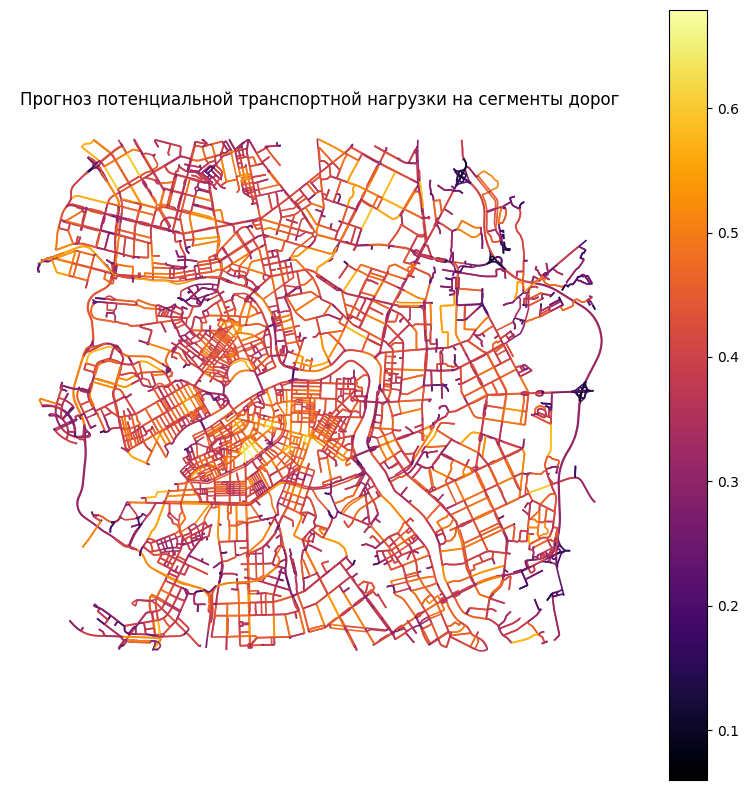

In [36]:
# TODO: прогноз для всех сегментов
roads["predicted_traffic_load"] = best_model_optimized.predict(X)

# Возвращаем геометрию в WGS84 для удобной визуализации
roads_wgs = gpd.GeoDataFrame(roads, geometry="geometry", crs=edges_m.crs).to_crs(4326)

fig, ax = plt.subplots(figsize=(10, 10))
roads_wgs.plot(
    ax=ax,
    column="predicted_traffic_load",
    linewidth=1.2,
    legend=True,
    cmap="inferno"
)
ax.set_title("Прогноз потенциальной транспортной нагрузки на сегменты дорог")
ax.set_axis_off()
plt.show()